In [1]:
# ─────────────────────────────────────────
# 1. IMPORTATIONS
# ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score,
                             roc_auc_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliothèques importées avec succès")

✅ Bibliothèques importées avec succès


In [2]:
# ─────────────────────────────────────────
# 2. CHARGEMENT DES DONNÉES
# ─────────────────────────────────────────
np.random.seed(42)
n_samples = 5000

n_normal = int(n_samples * 0.95)
n_fraud  = n_samples - n_normal

normal = pd.DataFrame({
    'montant':       np.random.exponential(scale=80,  size=n_normal),
    'heure':         np.random.randint(0, 24,          size=n_normal),
    'distance_km':   np.random.exponential(scale=5,   size=n_normal),
    'nb_trans_jour': np.random.poisson(lam=3,          size=n_normal),
    'score_risque':  np.random.beta(2, 8,              size=n_normal),
    'Fraude': 0
})

fraud = pd.DataFrame({
    'montant':       np.random.exponential(scale=400,          size=n_fraud),
    'heure':         np.random.choice([0,1,2,3,22,23],         size=n_fraud),
    'distance_km':   np.random.exponential(scale=200,          size=n_fraud),
    'nb_trans_jour': np.random.poisson(lam=10,                 size=n_fraud),
    'score_risque':  np.random.beta(8, 2,                      size=n_fraud),
    'Fraude': 1
})

df = pd.concat([normal, fraud], ignore_index=True).sample(frac=1, random_state=42)
df = df.reset_index(drop=True)

print(f"📊 Shape du dataset : {df.shape}")
print(f"\n🔍 Aperçu des données :")
df.head()

📊 Shape du dataset : (5000, 6)

🔍 Aperçu des données :


,montant,heure,distance_km,nb_trans_jour,score_risque,Fraude
0,52.188351,20,1.321608,1,0.089837,0
1,5.958559,17,0.045232,2,0.154328,0
2,4.302027,12,1.853613,3,0.169433,0
3,34.550289,2,1.536684,3,0.281815,0
4,368.096105,22,2.707555,1,0.316894,0


In [3]:
# ─────────────────────────────────────────
# 3. EXPLORATION DES DONNÉES (EDA)
# ─────────────────────────────────────────

# 3.1 Infos générales
print("📋 Informations générales :")
print(df.info())

# 3.2 Statistiques
print("\n📈 Statistiques descriptives :")
df.describe().round(2)

📋 Informations générales :
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   montant        5000 non-null   float64
 1   heure          5000 non-null   int64  
 2   distance_km    5000 non-null   float64
 3   nb_trans_jour  5000 non-null   int32  
 4   score_risque   5000 non-null   float64
 5   Fraude         5000 non-null   int64  
dtypes: float64(3), int32(1), int64(2)
memory usage: 215.0 KB
None

📈 Statistiques descriptives :


,montant,heure,distance_km,nb_trans_jour,score_risque,Fraude
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,95.01,11.38,14.81,3.37,0.23,0.05
std,139.91,7.13,59.98,2.38,0.18,0.22
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,23.51,5.00,1.53,2.00,0.11,0.00
50%,58.63,11.00,3.64,3.00,0.19,0.00
75%,118.62,17.00,7.70,4.00,0.29,0.00
max,3092.10,23.00,1082.38,19.00,0.99,1.00


In [4]:
# 3.3 Valeurs manquantes
print("❌ Valeurs manquantes par colonne :")
print(df.isnull().sum())

# 3.4 Distribution cible
print("\n🎯 Distribution de la cible (Fraude) :")
print(df['Fraude'].value_counts())
print("   0 = Normale | 1 = Fraude")

❌ Valeurs manquantes par colonne :
montant          0
heure            0
distance_km      0
nb_trans_jour    0
score_risque     0
Fraude           0
dtype: int64

🎯 Distribution de la cible (Fraude) :
Fraude
0    4750
1     250
Name: count, dtype: int64
   0 = Normale | 1 = Fraude


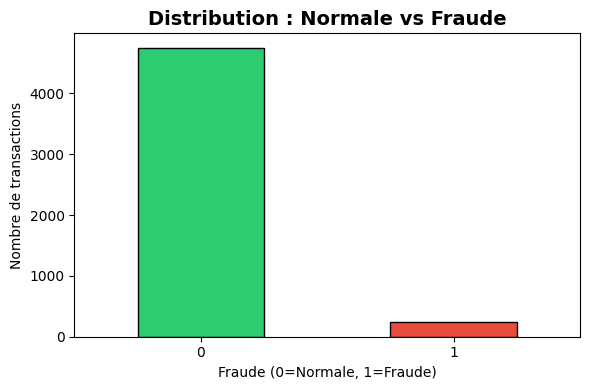

✅ Graphique sauvegardé


In [5]:
# 3.5 Graphique distribution cible
plt.figure(figsize=(6, 4))
df['Fraude'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'], edgecolor='black')
plt.title('Distribution : Normale vs Fraude', fontsize=14, fontweight='bold')
plt.xlabel('Fraude (0=Normale, 1=Fraude)')
plt.ylabel("Nombre de transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('distribution_cible.png', dpi=150)
plt.show()
print("✅ Graphique sauvegardé")

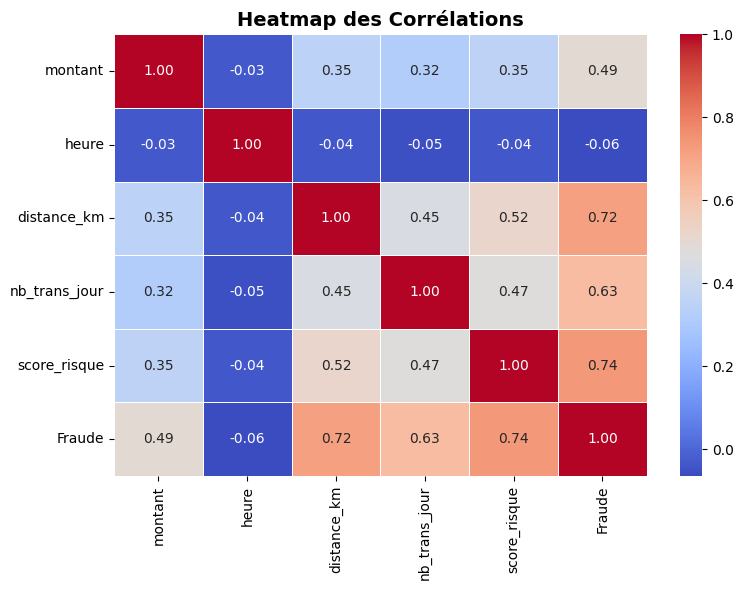

In [6]:
# 3.6 Heatmap des corrélations
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap des Corrélations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_correlations.png', dpi=150)
plt.show()

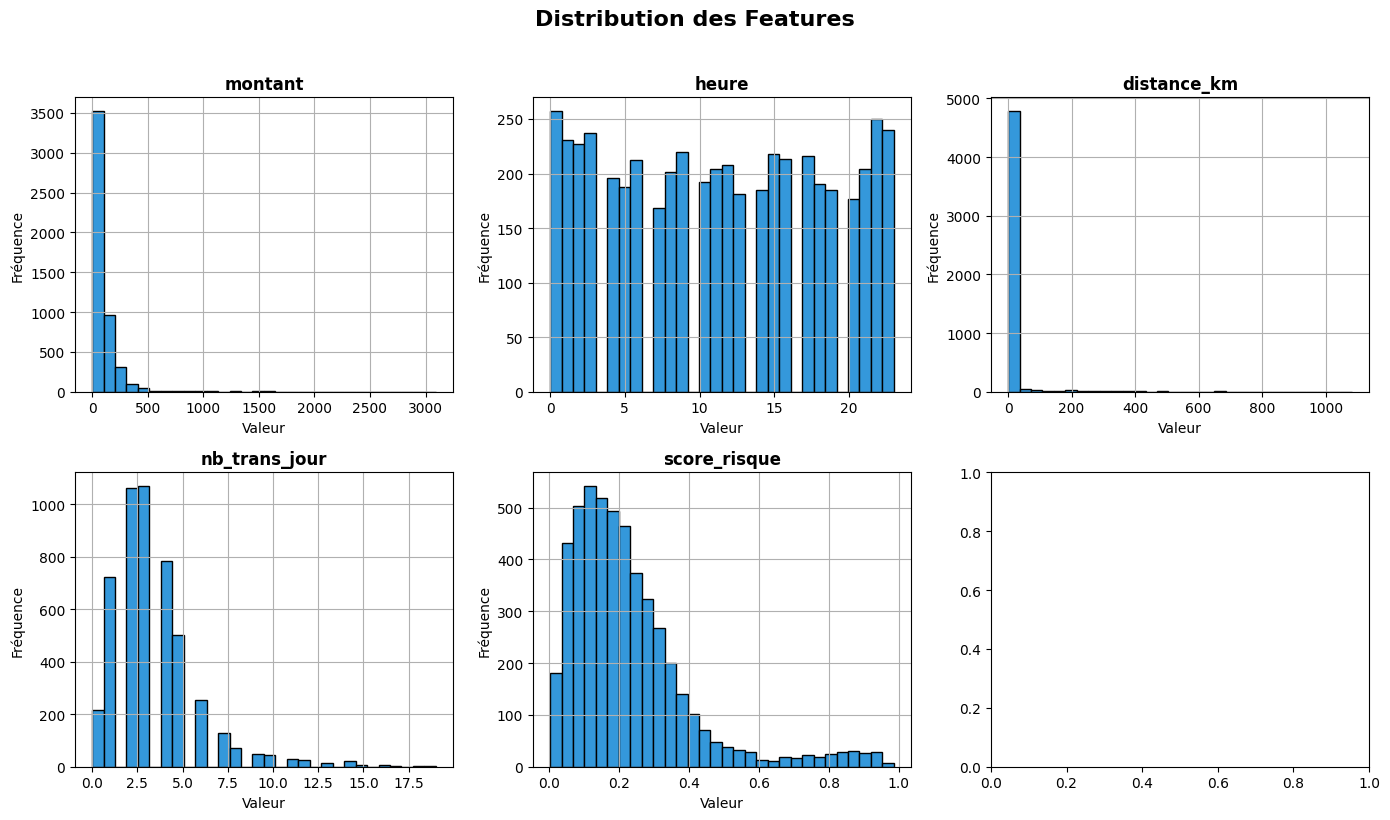

✅ Distributions sauvegardées


In [7]:
# 3.7 Distribution de chaque feature
features = df.columns[:-1]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(features):
    ax = axes[i//3][i%3]
    df[col].hist(ax=ax, bins=30, color='#3498db', edgecolor='black')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')

plt.suptitle('Distribution des Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribution_features.png', dpi=150)
plt.show()
print("✅ Distributions sauvegardées")

In [8]:
# ─────────────────────────────────────────
# 4. PRÉTRAITEMENT DES DONNÉES
# ─────────────────────────────────────────

# 4.1 Valeurs manquantes
df_clean = df.copy()
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"   ✅ {col} : remplacé par médiane ({median_val:.2f})")

print(f"\n✅ Valeurs manquantes après traitement : {df_clean.isnull().sum().sum()}")

# 4.2 Séparation X / y
X = df_clean.drop('Fraude', axis=1)
y = df_clean['Fraude']
print(f"\n📐 X shape : {X.shape}")
print(f"📐 y shape : {y.shape}")

# 4.3 Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n✂️  Train : {X_train.shape[0]} échantillons")
print(f"✂️  Test  : {X_test.shape[0]} échantillons")

# 4.4 Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\n✅ Normalisation effectuée (StandardScaler)")


✅ Valeurs manquantes après traitement : 0

📐 X shape : (5000, 5)
📐 y shape : (5000,)

✂️  Train : 4000 échantillons
✂️  Test  : 1000 échantillons

✅ Normalisation effectuée (StandardScaler)


In [9]:
# ─────────────────────────────────────────
# 5. ENTRAÎNEMENT DU MODÈLE
# ─────────────────────────────────────────
print("🤖 Entraînement du Random Forest...")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)
print("✅ Modèle entraîné avec succès !")

🤖 Entraînement du Random Forest...
✅ Modèle entraîné avec succès !


In [10]:
# ─────────────────────────────────────────
# 6. ÉVALUATION DU MODÈLE
# ─────────────────────────────────────────
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc      = roc_auc_score(y_test, y_proba)

print(f"🎯 Accuracy : {accuracy*100:.2f}%")
print(f"🎯 Score AUC : {auc:.4f}  (1.0 = parfait)")
print(f"\n📊 Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=['Normale', 'Fraude']))

🎯 Accuracy : 99.70%
🎯 Score AUC : 1.0000  (1.0 = parfait)

📊 Rapport de classification :
              precision    recall  f1-score   support

     Normale       1.00      1.00      1.00       950
      Fraude       1.00      0.94      0.97        50

    accuracy                           1.00      1000
   macro avg       1.00      0.97      0.98      1000
weighted avg       1.00      1.00      1.00      1000



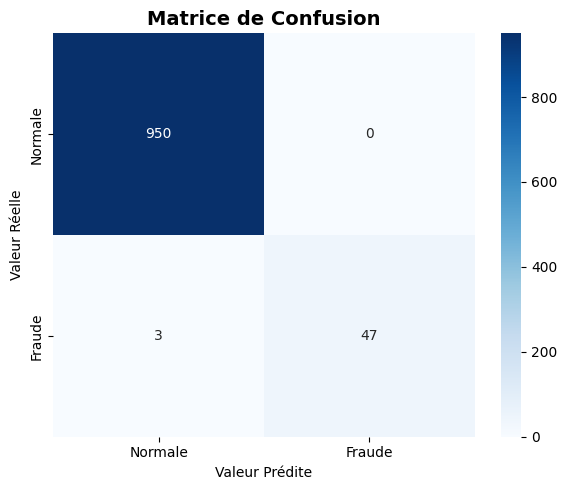

In [11]:
# 6.1 Matrice de confusion
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normale', 'Fraude'],
            yticklabels=['Normale', 'Fraude'])
plt.title('Matrice de Confusion', fontsize=14, fontweight='bold')
plt.ylabel('Valeur Réelle')
plt.xlabel('Valeur Prédite')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

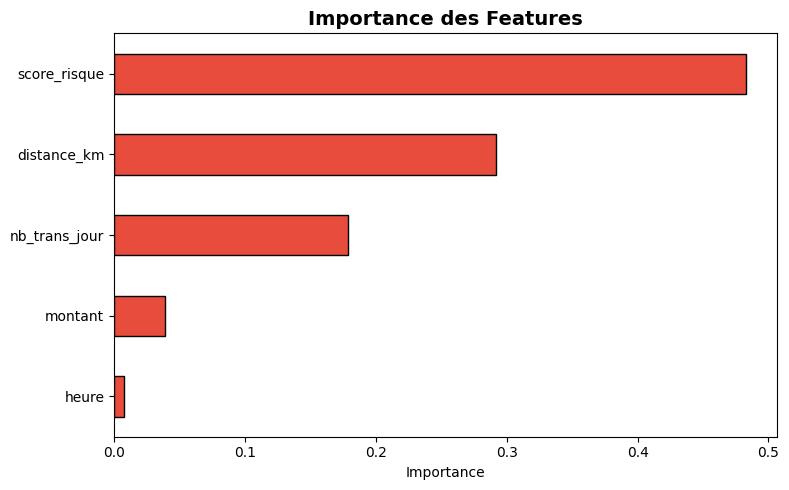


🔑 Top 3 features les plus importantes :
score_risque     0.482731
distance_km      0.291761
nb_trans_jour    0.178632
dtype: float64


In [12]:
# 6.2 Importance des features
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#e74c3c', edgecolor='black')
plt.title('Importance des Features', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\n🔑 Top 3 features les plus importantes :")
print(importances.sort_values(ascending=False).head(3))

In [13]:
# ─────────────────────────────────────────
# 7. SAUVEGARDE DU MODÈLE (joblib)
# ─────────────────────────────────────────
joblib.dump(model,  'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("💾 Modèle sauvegardé  → model.pkl")
print("💾 Scaler sauvegardé  → scaler.pkl")

model_test  = joblib.load('model.pkl')
scaler_test = joblib.load('scaler.pkl')
print("✅ Vérification : modèle rechargé avec succès !")

💾 Modèle sauvegardé  → model.pkl
💾 Scaler sauvegardé  → scaler.pkl
✅ Vérification : modèle rechargé avec succès !


In [14]:
# ─────────────────────────────────────────
# 8. TEST MANUEL (simulation utilisateur)
# ─────────────────────────────────────────
print("🧪 Test avec un échantillon fictif :")
print("   montant=850, heure=2, distance=300km, nb_trans=12, score_risque=0.9")

sample        = np.array([[850.0, 2, 300.0, 12, 0.9]])
sample_scaled = scaler_test.transform(sample)
prediction    = model_test.predict(sample_scaled)
proba         = model_test.predict_proba(sample_scaled)

if prediction[0] == 1:
    print(f"\n🚨 Résultat : FRAUDE DÉTECTÉE")
else:
    print(f"\n✅ Résultat : TRANSACTION NORMALE")

print(f"   Probabilité fraude  : {proba[0][1]*100:.1f}%")
print(f"   Probabilité normale : {proba[0][0]*100:.1f}%")

print("\n" + "="*50)
print("🎉 Notebook terminé avec succès !")
print("   Prochaine étape → streamlit run app.py")
print("="*50)

🧪 Test avec un échantillon fictif :
   montant=850, heure=2, distance=300km, nb_trans=12, score_risque=0.9

🚨 Résultat : FRAUDE DÉTECTÉE
   Probabilité fraude  : 100.0%
   Probabilité normale : 0.0%

🎉 Notebook terminé avec succès !
   Prochaine étape → streamlit run app.py
